# DeepFashion Try-On

Towards Photo-Realistic Virtual Try-On by Adaptively Generating↔Preserving Image Content, CVPR'20.

![](https://github.com/switchablenorms/DeepFashion_Try_On/raw/master/images/tryon.png)

## For inferencing ACGPN!

ACGPN repo: https://github.com/switchablenorms/DeepFashion_Try_On

This notebook is hard coded for inferencing one image at a time.

Notebook by [Levin Dabhi](https://levindabhi.github.io/)

```
author = {Yang, Han and Zhang, Ruimao and Guo, Xiaobao and Liu, Wei and Zuo, Wangmeng and Luo, Ping},
title = {Towards Photo-Realistic Virtual Try-On by Adaptively Generating-Preserving Image Content},
booktitle = {IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR)},
month = {June},
year = {2020}
}

@inproceedings{ge2021disentangled,
  title={Disentangled Cycle Consistency for Highly-realistic Virtual Try-On},
  author={Ge, Chongjian and Song, Yibing and Ge, Yuying and Yang, Han and Liu, Wei and Luo, Ping},
  booktitle={Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition},
  pages={16928--16937},
  year={2021}
}

@inproceedings{yang2022full,
title = {Full-Range Virtual Try-On With Recurrent Tri-Level Transform},
author = {Yang, Han and Yu, Xinrui and Liu, Ziwei},
booktitle = {Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition},
pages = {3460--3469}
year = {2022}
}
```

## ACGPN

- Original: https://github.com/levindabhi/ACGPN.git
- Modified: https://github.com/kairess/ACGPN.git

In [ ]:
!git clone https://github.com/kairess/ACGPN.git
%cd ACGPN

Cloning into 'ACGPN'...
remote: Enumerating objects: 165, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 165 (delta 21), reused 19 (delta 18), pack-reused 141 (from 1)
Receiving objects: 100% (165/165), 303.15 KiB | 21.65 MiB/s, done.
Resolving deltas: 100% (62/62), done.
/content/ACGPN


## Dependencies

In [ ]:
!pip install -U --no-cache-dir gdown --pre -qq
!pip install ninja -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.9/422.9 kB 26.7 MB/s eta 0:00:00


In [ ]:
import gdown
import numpy as np
from PIL import Image
import IPython
import gdown
import os
import sys
import time

from predict_pose import generate_pose_keypoints

In [ ]:
for dir_name in [
    "Data_preprocessing/test_color",
    "Data_preprocessing/test_colormask",
    "Data_preprocessing/test_edge",
    "Data_preprocessing/test_img",
    "Data_preprocessing/test_label",
    "Data_preprocessing/test_mask",
    "Data_preprocessing/test_pose",
    "inputs",
    "inputs/img",
    "inputs/cloth"
]:
    if not os.path.exists(dir_name):
        os.makedirs(dir_name)

In [ ]:
!git clone https://github.com/levindabhi/Self-Correction-Human-Parsing-for-ACGPN.git
!git clone https://github.com/levindabhi/U-2-Net.git

Cloning into 'Self-Correction-Human-Parsing-for-ACGPN'...
remote: Enumerating objects: 769, done.
remote: Counting objects: 100% (202/202), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 769 (delta 103), reused 94 (delta 94), pack-reused 567 (from 1)
Receiving objects: 100% (769/769), 3.89 MiB | 13.24 MiB/s, done.
Resolving deltas: 100% (184/184), done.
Cloning into 'U-2-Net'...
remote: Enumerating objects: 822, done.
remote: Counting objects: 100% (334/334), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 822 (delta 312), reused 299 (delta 299), pack-reused 488 (from 1)
Receiving objects: 100% (822/822), 30.71 MiB | 12.15 MiB/s, done.
Resolving deltas: 100% (391/391), done.


## 사전학습 모델 다운로드

### 포즈 예측 모델

In [ ]:
!gdown 1virNy5geSvTA6Qkqv0HfujySA2N_Qx4q -O pose/pose_iter_440000.caffemodel

Downloading...
From (original): https://drive.google.com/uc?id=1virNy5geSvTA6Qkqv0HfujySA2N_Qx4q
From (redirected): https://drive.google.com/uc?id=1virNy5geSvTA6Qkqv0HfujySA2N_Qx4q&confirm=t&uuid=9214e788-14e1-4870-a31f-4f52f1b8bbf9
To: /content/ACGPN/pose/pose_iter_440000.caffemodel
100% 209M/209M [00:04<00:00, 44.9MB/s]


### 휴먼 세그멘테이션 마스크 생성 모델

In [ ]:
gdown.download('https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH', 'lip_final.pth', quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH
From (redirected): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH&confirm=t&uuid=0caa6067-664d-4b13-b0e8-37e908ac143e
To: /content/ACGPN/lip_final.pth
100%|██████████| 267M/267M [00:02<00:00, 131MB/s] 


'lip_final.pth'

### U2Net 모델

옷 마스크 추출 모델

In [ ]:
%cd U-2-Net
os.makedirs('saved_models', exist_ok=True)
os.makedirs('saved_models/u2net', exist_ok=True)
os.makedirs('saved_models/u2netp', exist_ok=True)

!gdown 1rbSTGKAE-MTxBYHd-51l2hMOQPT_7EPy -O saved_models/u2netp/u2netp.pth
!gdown 1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ -O saved_models/u2net/u2net.pth

import u2net_load
import u2net_run

u2net = u2net_load.model(model_name='u2netp')

%cd ..

/content/ACGPN/U-2-Net
Downloading...
From: https://drive.google.com/uc?id=1rbSTGKAE-MTxBYHd-51l2hMOQPT_7EPy
To: /content/ACGPN/U-2-Net/saved_models/u2netp/u2netp.pth
100% 4.68M/4.68M [00:00<00:00, 153MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ
From (redirected): https://drive.google.com/uc?id=1ao1ovG1Qtx4b7EoskHXmi2E9rp5CHLcZ&confirm=t&uuid=ee6f247b-2cc5-4d03-9568-54ef6afacbb9
To: /content/ACGPN/U-2-Net/saved_models/u2net/u2net.pth
100% 176M/176M [00:05<00:00, 34.9MB/s]
...load U2NEP---4.7 MB
/content/ACGPN


### ACGPN 모델

In [ ]:
!mkdir checkpoints

gdown.download('https://drive.google.com/uc?id=1UWT6esQIU_d4tUm8cjxDKMhB8joQbrFx', output='checkpoints/ACGPN_checkpoints.zip', quiet=False)

!unzip checkpoints/ACGPN_checkpoints.zip -d checkpoints

Downloading...
From (original): https://drive.google.com/uc?id=1UWT6esQIU_d4tUm8cjxDKMhB8joQbrFx
From (redirected): https://drive.google.com/uc?id=1UWT6esQIU_d4tUm8cjxDKMhB8joQbrFx&confirm=t&uuid=dbb64097-ece7-43c3-b1a9-93fdbc274ef0
To: /content/ACGPN/checkpoints/ACGPN_checkpoints.zip
100%|██████████| 524M/524M [00:09<00:00, 54.6MB/s]


Archive:  checkpoints/ACGPN_checkpoints.zip
   creating: checkpoints/label2city/
  inflating: checkpoints/label2city/latest_net_G.pth  
  inflating: checkpoints/label2city/latest_net_G1.pth  
  inflating: checkpoints/label2city/latest_net_G2.pth  
  inflating: checkpoints/label2city/latest_net_U.pth  
  inflating: checkpoints/label2city/opt.txt  


## VITON 데이터셋

https://drive.google.com/uc?id=1tE7hcVFm8Td8kRh5iYRBSDFdvZIkbUIR

## AI허브 패션 데이터셋

https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=78

![](https://aihub.or.kr/web-nas/aihub21/files/public/inline-images/65_%ED%8C%A8%EC%85%98%EC%83%81%ED%92%88%EB%B0%8F%EC%B0%A9%EC%9A%A9%EC%98%81%EC%83%81_%EB%8C%80%ED%91%9C%EB%8F%84.PNG)

## 전처리

### 옷 마스크 추출

In [ ]:
sorted(os.listdir('inputs/cloth'))

['.ipynb_checkpoints', '000200_1.jpg']

Generating mask for: cloth_1732439097.png
Saving output at Data_preprocessing/test_edge/cloth_1732439097.png
Generating mask for: cloth_1732436299.png
Saving output at Data_preprocessing/test_edge/cloth_1732436299.png


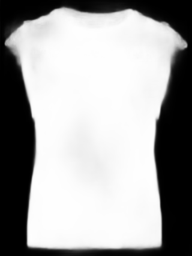

In [ ]:
import os
from PIL import Image

# 디렉토리가 아닌 실제 파일만 필터링
cloth_files = [f for f in os.listdir('inputs/cloth')
               if not f.startswith('.') and  # 숨김 파일 제외
               not os.path.isdir(os.path.join('inputs/cloth', f))]  # 디렉토리 제외

cloth_path = os.path.join('inputs/cloth', sorted(cloth_files)[0])
cloth = Image.open(cloth_path)
cloth = cloth.resize((192, 256), Image.BICUBIC).convert('RGB')
cloth.save(os.path.join('Data_preprocessing/test_color', cloth_name))

u2net_run.infer(u2net, 'Data_preprocessing/test_color', 'Data_preprocessing/test_edge')

Image.open(f'Data_preprocessing/test_edge/{cloth_name}')

In [ ]:
#위 파일로 수정#
'''
cloth_name = f'cloth_{int(time.time())}.png'

cloth_path = os.path.join('inputs/cloth', sorted(os.listdir('inputs/cloth'))[0])
cloth = Image.open(cloth_path)
cloth = cloth.resize((192, 256), Image.BICUBIC).convert('RGB')
cloth.save(os.path.join('Data_preprocessing/test_color', cloth_name))

u2net_run.infer(u2net, 'Data_preprocessing/test_color', 'Data_preprocessing/test_edge')

Image.open(f'Data_preprocessing/test_edge/{cloth_name}')
'''

IsADirectoryError: [Errno 21] Is a directory: '/content/ACGPN/inputs/cloth/.ipynb_checkpoints'

### 모델 포즈, 세그멘테이션

In [ ]:
sorted(os.listdir('inputs/img'))

['000118_0.jpg']

In [ ]:
img_name = f'img_{int(time.time())}.png'

img_path = os.path.join('inputs/img', sorted(os.listdir('inputs/img'))[0])
img = Image.open(img_path)
img = img.resize((192,256), Image.BICUBIC)

img_path = os.path.join('Data_preprocessing/test_img', img_name)
img.save(img_path)

!python3 Self-Correction-Human-Parsing-for-ACGPN/simple_extractor.py --dataset 'lip' --model-restore 'lip_final.pth' --input-dir 'Data_preprocessing/test_img' --output-dir 'Data_preprocessing/test_label'

pose_path = os.path.join('Data_preprocessing/test_pose', img_name.replace('.png', '_keypoints.json'))
generate_pose_keypoints(img_path, pose_path)

/usr/local/lib/python3.10/dist-packages/torch/utils/cpp_extension.py:1964: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/content/ACGPN/Self-Correction-Human-Parsing-for-ACGPN/simple_extractor.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_sa

## 추론

In [ ]:
!rm -rf Data_preprocessing/test_pairs.txt
with open('Data_preprocessing/test_pairs.txt', 'w') as f:
    f.write(f'{img_name} {cloth_name}')

In [ ]:
!python test.py

?
------------ Options -------------
aspect_ratio: 1.0
batchSize: 1
checkpoints_dir: ./checkpoints
cluster_path: features_clustered_010.npy
continue_train: False
data_type: 32
datapairs: test_pairs.txt
dataroot: Data_preprocessing/
display_winsize: 512
engine: None
export_onnx: None
fineSize: 512
gpu_ids: [0]
how_many: 1000
input_nc: 3
isTrain: False
label_nc: 20
loadSize: 512
max_dataset_size: inf
model: pix2pixHD
nThreads: 1
n_blocks_global: 4
n_blocks_local: 3
n_downsample_global: 4
n_local_enhancers: 1
name: label2city
netG: global
ngf: 64
niter_fix_global: 0
no_flip: False
norm: instance
ntest: inf
onnx: None
output_nc: 3
phase: test
resize_or_crop: scale_width
results_dir: ./results/
serial_batches: True
tf_log: False
use_dropout: False
use_encoded_image: False
verbose: False
which_epoch: latest
-------------- End ----------------
CustomDatasetDataLoader
dataset [AlignedDataset] was created
Data_preprocessing/test_label label
Data_preprocessing/test_img img
Data_preprocessing/tes

## 결과

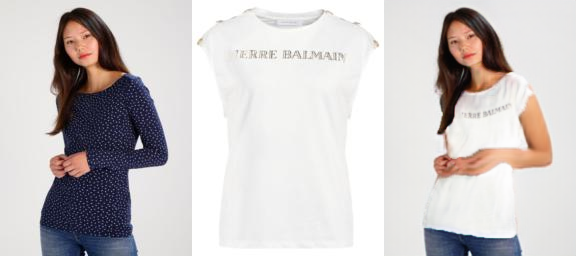

In [ ]:
output_grid = np.concatenate([
    np.array(Image.open(f'Data_preprocessing/test_img/{img_name}')),
    np.array(Image.open(f'Data_preprocessing/test_color/{cloth_name}')),
    np.array(Image.open(f'results/test/try-on/{img_name}'))
], axis=1)

image_grid = Image.fromarray(output_grid)

image_grid

In [ ]:
!pip freeze > colab_requirements.txt